# Case Study - Healthcare Domain


## SPRINT 1 - EDA


### Task - Exploratory Data Analysis

## STEP 1 : Load Libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## STEP 2:Load Dataset

In [99]:
data=pd.read_csv("insurance (1).csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## STEP 3: Basic Information

In [100]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [101]:
data.shape

(1338, 7)

In [102]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [103]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [104]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [105]:
data.duplicated().sum()

np.int64(1)

## STEP 4:Explore Data Distribution

#### Numerical Columns

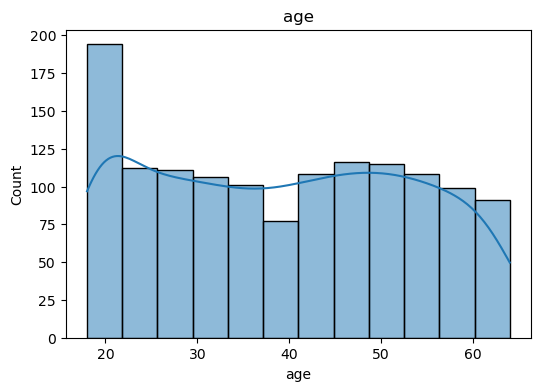

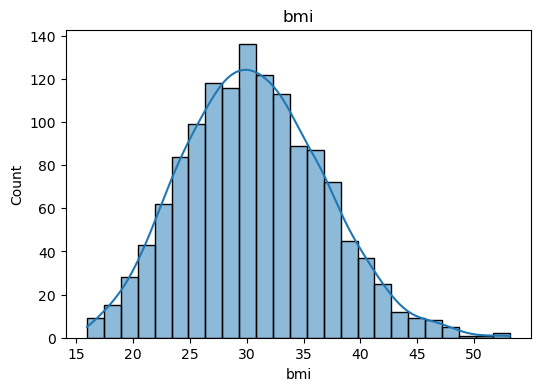

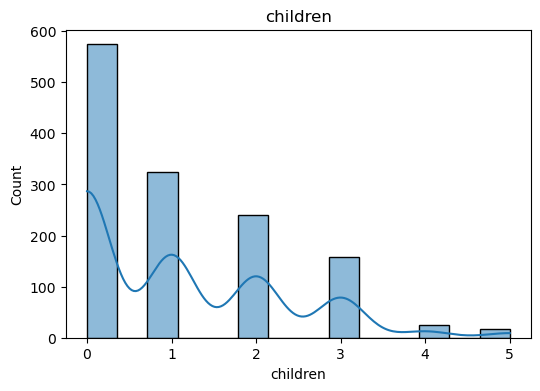

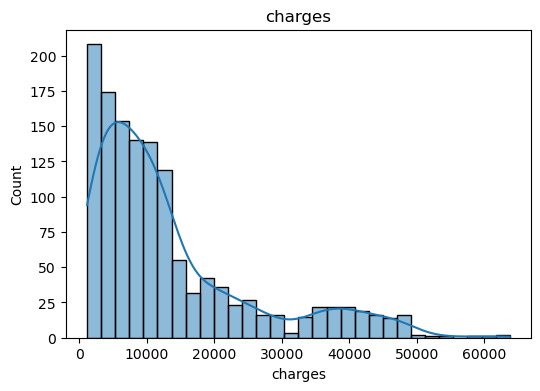

In [106]:
num_cols=data.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True)
    plt.title(col)
    plt.show()

#### Categorical Columns

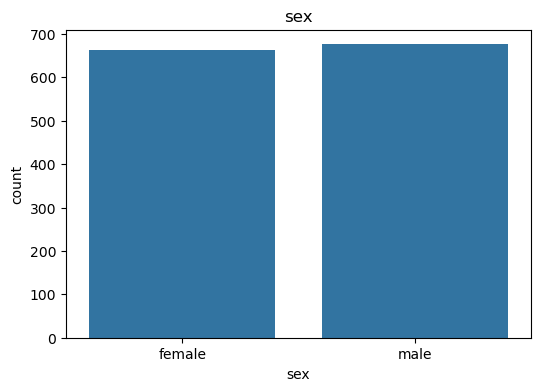

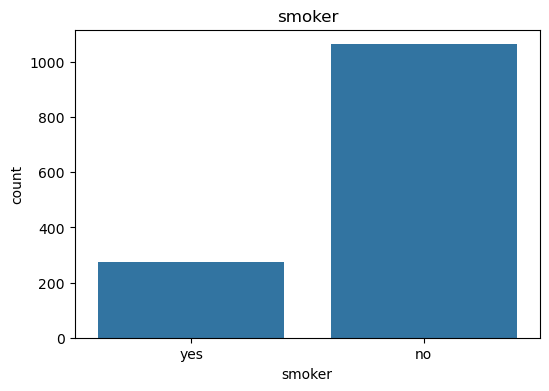

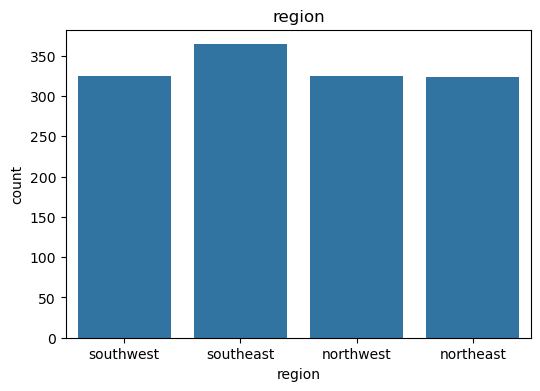

In [12]:
cat_cols=data.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[col])
    plt.title(col)
    plt.show()


## STEP 5: Outlier Detection

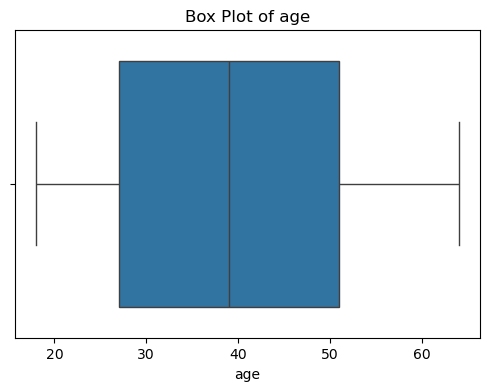

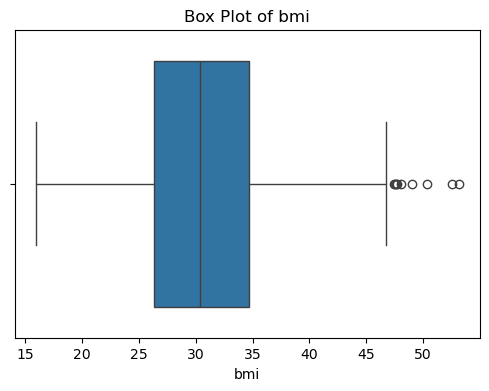

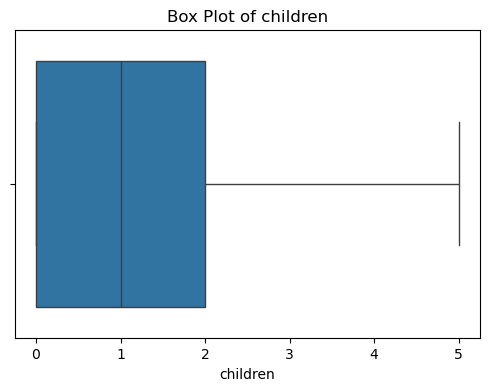

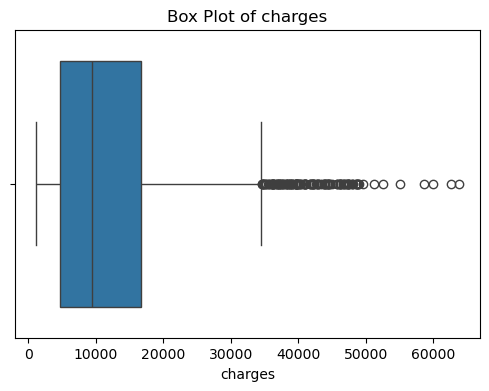

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [ ]:
# remove outliers

In [14]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [15]:
print("Shape after removing outliers:", data.shape)

Shape after removing outliers: (1191, 7)


## STEP 6 : Correlation

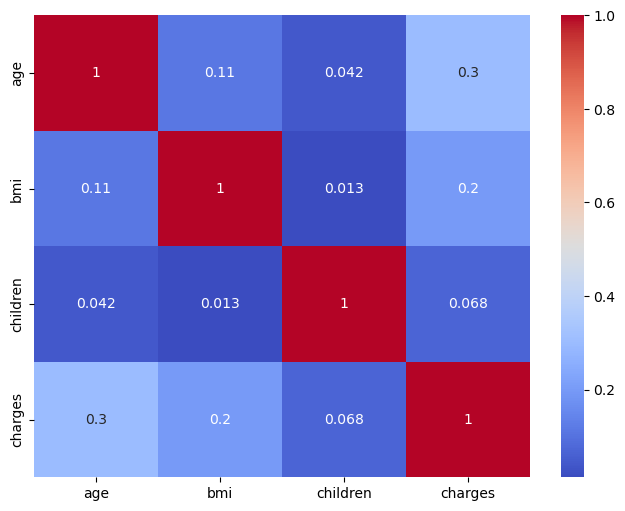

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()


- charges increases with age.
- Smokers have much higher medical charges than non-smokers.
- Higher BMI is associated with higher charges.
- Sex and region have relatively little effect on charges.

## step 7:Feature vs Charges


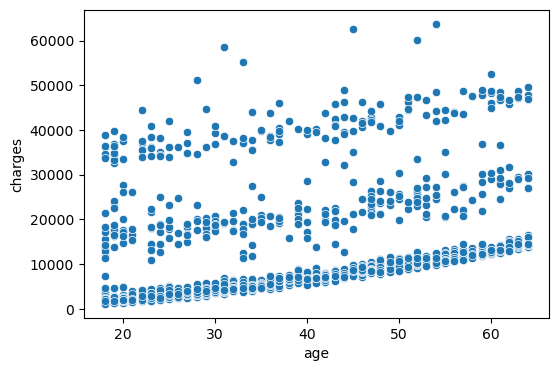

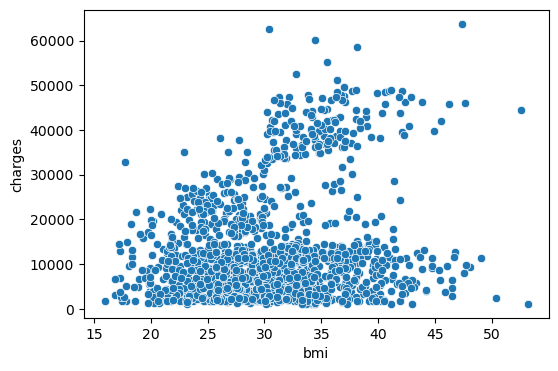

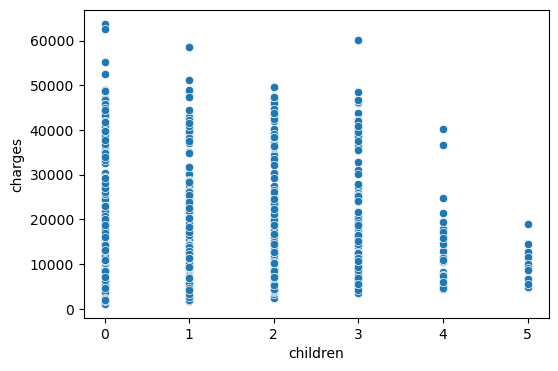

In [109]:
# numerical
for col in num_cols:
    if col!="charges":
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=data[col],y=data["charges"])
        plt.show()

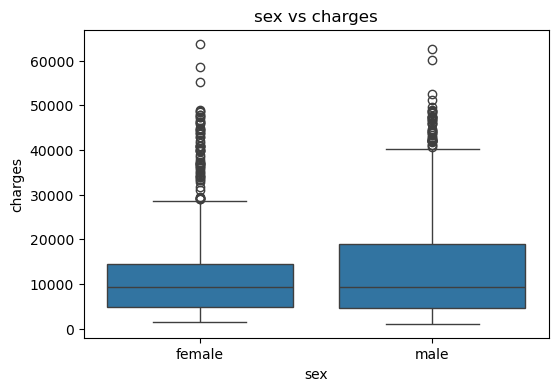

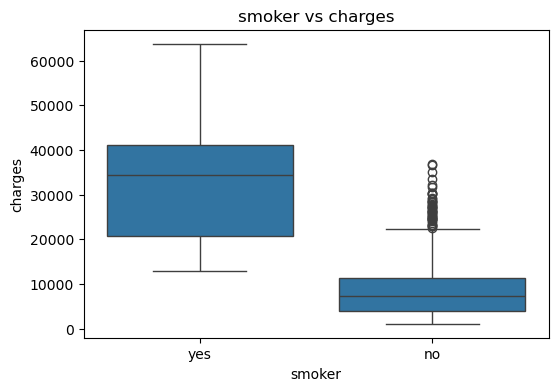

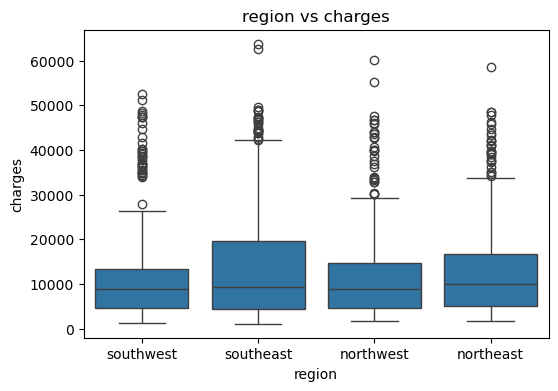

In [110]:
# categorical
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col],y=data["charges"])
    plt.title(f"{col} vs charges")
    plt.show()

# SPRINT 2 - Model Building

## Task - Data Preparation and Model Building


### Step - 2: Identify the input and output/target variables. 

In [111]:
# Step 2: Input and Output Variables

X = data.drop("charges", axis=1)
y = data["charges"]



step 2: Identify the type of ML Task.
- Type of ML Task:Regression
- Reason:The target variable (charges) is a continuous numerical value.

step 2: Identify the Evaluation Metric
- Evaluation Metric:Mean Absolute Error (MAE)
- Reason:MAE measures the average prediction error. Lower MAE indicates better prediction accuracy. 

### Step - 3: Split the dataset into Training and Testing (recommended 75:25 split)

In [132]:
from sklearn.model_selection import train_test_split

In [133]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42)

### Step - 4: Data preparation on train data:For Numerical Variables 


In [134]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = ['age', 'bmi', 'children']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

In [115]:
X_train[num_cols]

,age,bmi,children
693,0.130435,0.207022,0.0
1297,0.217391,0.283831,0.4
634,0.717391,0.638687,0.2
1022,0.630435,0.541297,0.2
178,0.608696,0.348130,0.4
...,...,...,...
1095,0.000000,0.414044,0.8
1130,0.456522,0.212806,1.0
1294,0.869565,0.247915,0.0
860,0.413043,0.851224,0.4


##### For Categorical - LabelEncoding or OneHotEncoding

In [135]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
X_train['sex'] = le_sex.fit_transform(X_train['sex'])

le_smoker = LabelEncoder()
X_train['smoker'] = le_smoker.fit_transform(X_train['smoker'])

In [139]:
print(X_train.dtypes)

age                 float64
sex                   int64
bmi                 float64
children            float64
smoker                int64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object


In [137]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
region_encoded = ohe.fit_transform(X_train[['region']])
region_cols = ohe.get_feature_names_out(['region'])

region_df = pd.DataFrame(region_encoded, columns=region_cols, index=X_train.index)
X_train = pd.concat([X_train.drop('region', axis=1), region_df], axis=1)

In [140]:
X_train

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
693,0.130435,1,0.207022,0.0,0,1.0,0.0,0.0
1297,0.217391,0,0.283831,0.4,0,0.0,1.0,0.0
634,0.717391,1,0.638687,0.2,0,0.0,0.0,1.0
1022,0.630435,1,0.541297,0.2,1,0.0,1.0,0.0
178,0.608696,0,0.348130,0.4,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
1095,0.000000,0,0.414044,0.8,0,0.0,0.0,0.0
1130,0.456522,0,0.212806,1.0,0,0.0,1.0,0.0
1294,0.869565,1,0.247915,0.0,0,0.0,0.0,0.0
860,0.413043,0,0.851224,0.4,1,0.0,0.0,1.0


### Step - 5: Data preparation on test data:
-   For Numerical Variables - Standardization 
-   For Categorical - LabelEncoding or OneHotEncoding 

In [141]:
# Recover raw test data using the original dataframe and the test index
X_test[num_cols] = data.loc[X_test.index, num_cols]

# Now transform using the already-fitted scaler (fit on raw X_train)
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [142]:
X_test[num_cols]

,age,bmi,children
764,0.586957,0.247915,0.4
887,0.391304,0.378262,0.0
890,1.000000,0.293920,0.0
1293,0.608696,0.263250,0.6
259,0.021739,0.429379,0.0
...,...,...,...
342,0.913043,0.311811,0.0
308,0.869565,0.508609,0.0
1128,0.347826,0.453054,0.2
503,0.021739,0.384450,0.0


In [143]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1003, 8) (1003,)
(335, 6) (335,)


In [144]:
# Recover raw categorical columns for X_test from the original, untouched df
cat_cols = ['sex', 'smoker', 'region']
X_test[cat_cols] = data.loc[X_test.index, cat_cols]

# 1. Label Encoding — sex and smoker (binary, reuse fitted encoders from train)
X_test['sex'] = le_sex.transform(X_test['sex'])
X_test['smoker'] = le_smoker.transform(X_test['smoker'])

# 2. One-Hot Encoding — region (nominal, reuse fitted ohe from train)
region_encoded_test = ohe.transform(X_test[['region']])
region_cols_test = ohe.get_feature_names_out(['region'])
region_df_test = pd.DataFrame(region_encoded_test, columns=region_cols_test, index=X_test.index)

X_test = pd.concat([X_test.drop('region', axis=1), region_df_test], axis=1)

In [145]:
X_test

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
764,0.586957,0,0.247915,0.4,0,0.0,0.0,0.0
887,0.391304,0,0.378262,0.0,0,1.0,0.0,0.0
890,1.000000,0,0.293920,0.0,1,1.0,0.0,0.0
1293,0.608696,1,0.263250,0.6,0,1.0,0.0,0.0
259,0.021739,1,0.429379,0.0,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
342,0.913043,0,0.311811,0.0,0,0.0,0.0,0.0
308,0.869565,1,0.508609,0.0,0,0.0,0.0,0.0
1128,0.347826,1,0.453054,0.2,0,0.0,0.0,1.0
503,0.021739,1,0.384450,0.0,1,0.0,1.0,0.0


In [146]:
print(X_train.shape, X_test.shape)
print(X_train.columns.tolist() == X_test.columns.tolist())

(1003, 8) (335, 8)
True


### Step - 6: Model Training Phase

In [147]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. KNN
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

# 2. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 3. Support Vector Machine
svm = SVR()
svm.fit(X_train, y_train)

# 4. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# 5. Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print("All 5 models trained successfully.")

All 5 models trained successfully.


### Step - 7: Predict and evaluate each model separately using the correct evaluation metric. 

#### 1. KNN (K-Nearest Neighbors)

In [148]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Regressor:")
print("R2 Score :", r2_score(y_test, y_pred_knn))
print("MAE      :", mean_absolute_error(y_test, y_pred_knn))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_knn)))

KNN Regressor:
R2 Score : 0.7806426092675186
MAE      : 3570.2592792029855
RMSE     : 5753.180571670215


#### 2. Linear Regression

In [82]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print("R2 Score :", r2_score(y_test, y_pred_lr))
print("MAE      :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression:
R2 Score : 0.6364870238644291
MAE      : 2600.2527790336203
RMSE     : 4382.412661222512


#### 3. Support Vector Machine (SVR)

In [83]:
from sklearn.svm import SVR

svm = SVR()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Regressor:")
print("R2 Score :", r2_score(y_test, y_pred_svm))
print("MAE      :", mean_absolute_error(y_test, y_pred_svm))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_svm)))

SVM Regressor:
R2 Score : -0.06274603607681262
MAE      : 5619.696476566178
RMSE     : 7493.212645954207


#### 4. Decision Tree

In [84]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Regressor:")
print("R2 Score :", r2_score(y_test, y_pred_dt))
print("MAE      :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree Regressor:
R2 Score : 0.23592643972924954
MAE      : 3031.8790444127517
RMSE     : 6353.615019870657


#### 5. Random Forest

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Regressor:")
print("R2 Score :", r2_score(y_test, y_pred_rf))
print("MAE      :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest Regressor:
R2 Score : 0.6074372937484811
MAE      : 2523.380552918785
RMSE     : 4554.155233687841


In [91]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. KNN
y_pred_knn = knn.predict(X_test)
r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

# 2. Linear Regression
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# 3. SVM
y_pred_svm = svm.predict(X_test)
r2_svm = r2_score(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))

# 4. Decision Tree
y_pred_dt = dt.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# 5. Random Forest
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("All models evaluated successfully.")


All models evaluated successfully.


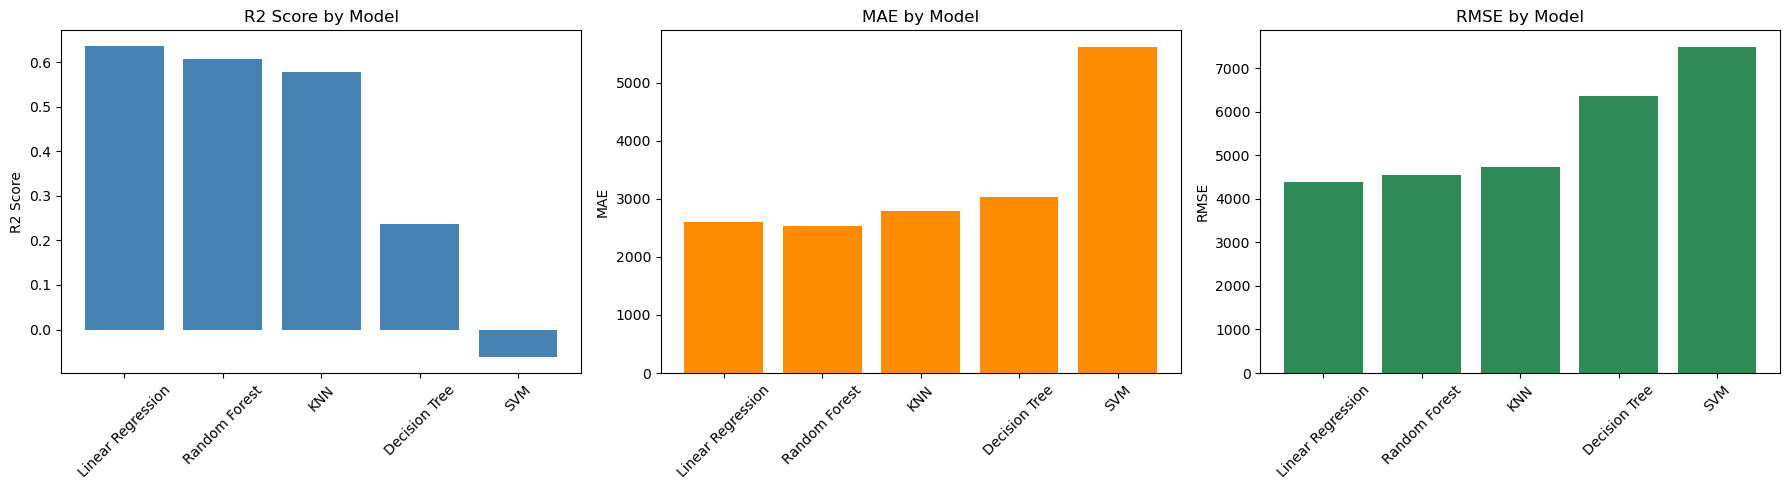

               Model  R2 Score          MAE         RMSE
0  Linear Regression  0.636487  2600.252779  4382.412661
1      Random Forest  0.607437  2523.380553  4554.155234
2                KNN  0.577919  2781.760694  4722.273873
3      Decision Tree  0.235926  3031.879044  6353.615020
4                SVM -0.062746  5619.696477  7493.212646


In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# Build the comparison dataframe (reuses values from Step 7)
comparison = pd.DataFrame({
    'Model': ['KNN', 'Linear Regression', 'SVM', 'Decision Tree', 'Random Forest'],
    'R2 Score': [r2_knn, r2_lr, r2_svm, r2_dt, r2_rf],
    'MAE': [mae_knn, mae_lr, mae_svm, mae_dt, mae_rf],
    'RMSE': [rmse_knn, rmse_lr, rmse_svm, rmse_dt, rmse_rf]
})

comparison = comparison.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

# Plot R2 Score comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(comparison['Model'], comparison['R2 Score'], color='steelblue')
axes[0].set_title('R2 Score by Model')
axes[0].set_ylabel('R2 Score')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(comparison['Model'], comparison['MAE'], color='darkorange')
axes[1].set_title('MAE by Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(comparison['Model'], comparison['RMSE'], color='seagreen')
axes[2].set_title('RMSE by Model')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(comparison)

In [97]:
data.shape

(1191, 7)